In [1]:
import sys
sys.path.insert(0, '../..')
import math
import numpy as np
import matplotlib.pyplot as plt 
import mssfp
import deepssfp
from deepssfp import dataloader, view, recon, dataformatter, deepssfp, models, plotlib

Generating 3d phantom:(1200, 434, 362)


  0%|          | 0/1200 [00:00<?, ?it/s]c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:64: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:91: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)
100%|██████████| 1200/1200 [00:23<00:00, 51.19it/s]


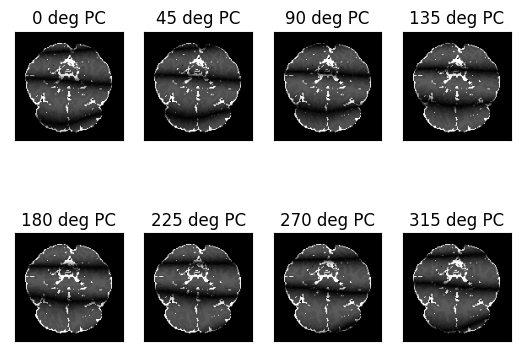

In [2]:
dataset = mssfp.generate_ssfp_dataset(N=128, npcs=8, f=500, alpha=np.deg2rad(60), sigma=0.0001, data_indices=[(None, None), (120,180)], rotate=True, deform=True)
data = dataset['M']
fieldmap = dataset['phantom']['offres']
T1 = dataset['phantom']['t1_map']
T2 = dataset['phantom']['t2_map']
data.shape
mssfp.plot_dataset(data, slice=0)

In [3]:
mode = 'BandRemoval:2'
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

(960, 128, 128, 8) (960, 128, 128, 2)


In [4]:
mode = 'BandRemoval:2'
model, history, ds, predictions = deepssfp.train(mode, epochs=400, input_data=data)

Training DataSet: (960, 128, 128, 8) (960, 128, 128, 2)
Test DataSet: (240, 128, 128, 8) (240, 128, 128, 2)
DL Model: 128, 128, 8, 2
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128    